In [70]:
import sys, os
from pathlib import Path
from dotenv import load_dotenv
import torch

PATH_PROJECT = os.path.join('..', '..')
sys.path.append(PATH_PROJECT)
env_file = os.path.join(PATH_PROJECT, '.env')
load_dotenv(env_file)

from rows2regionsGLAM.models import get_model
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.pred_processor import PredProcessor
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.pipeline import Pipeline
from pagerlib.dtypes import Region

from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset

from rows2regionsGLAM.utils.ploter import Ploter
import matplotlib.pyplot as plt

In [79]:
params = {"node_block":	{'linear_pred': [{'in': 15, 'out': 256, 'activation': 'gelu'}, {'in': 256, 'out': 512, 'activation': 'gelu'}], 'gnn': [('tag', {'batch_norm': True, 'concat': True, 'in': 512, 'in_gnn': 1024, 'out_gnn': 512, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3}), ('tag', {'batch_norm': False, 'concat': True, 'in': 1024, 'in_gnn': 1024, 'out_gnn': 512, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3})]},
"node_classifier_block":	{'linear_post': [{'in': 1536, 'out': 512, 'activation': 'gelu'}, {'in': 512, 'out': 64, 'activation': 'gelu'}, {'in': 64, 'out': 6, 'activation': 'none'}]},
"post_node_block":	{'linear_pred': [{'in': 1536, 'out': 1024, 'activation': 'gelu'}, {'in': 1024, 'out': 512, 'activation': 'gelu'}, {'in': 512, 'out': 256, 'activation': 'gelu'}], 'gnn': [('tag', {'batch_norm': True, 'concat': True, 'in': 256, 'in_gnn': 256, 'out_gnn': 256, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3}), ('tag', {'batch_norm': False, 'concat': True, 'in': 512, 'in_gnn': 256, 'out_gnn': 128, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3})]},
"edge_classifier_block":	{'linear_post': [{'in': 1314, 'out': 128, 'activation': 'gelu'}, {'in': 128, 'out': 32, 'activation': 'gelu'}, {'in': 32, 'out': 1, 'activation': 'none'}]}}
# model, num = get_model(path_model='big_model/result_top_20260507/row2region_GLAM_start_no_0',params=params)
model, num = get_model(path_model='row2region_GLAM_start_no_0_tmp_15',params=params)

In [80]:
loger = Loger()
tokenizer = RowGLAMTokenizer()
pred = PredProcessor(loger=loger, tokenizer=tokenizer)

In [81]:
test_dataset_name = os.environ['NAME_TEST_DATASET']
test_dataset_path = os.environ['TEST_PATH']
test_dataset_coco = os.environ['TEST_COCO_PATH']
cache_pdf = os.environ["CASH_PDF_PATH"]

coco_manager_test  = COCOManager(loger=loger, coco_path=test_dataset_coco,  name_dataset=test_dataset_name)
test_dataset = GLAMDataset(
    coco_manager=coco_manager_test,
    default_index=0,
    pred=pred,
    loger=loger,
    cache_dir=cache_pdf,
    pdf_dir=test_dataset_path,
)
test_dataset.train()
test_dataset.init()

(init) SIZE DATASET:  200
100.00 %

In [82]:
id2name = coco_manager_test.classes
name2id = {name:id_ for id_, name in id2name.items()}
# model.eval()
# torch.no_grad()
pipeline = Pipeline(pred=pred, model=model, model_id2name=id2name, dataset_name2id=name2id)
ploter = Ploter(conf={'loger': loger})


Файл: PMC2859684_00000.pdf
Нод: 73
Рёбер: 204


/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


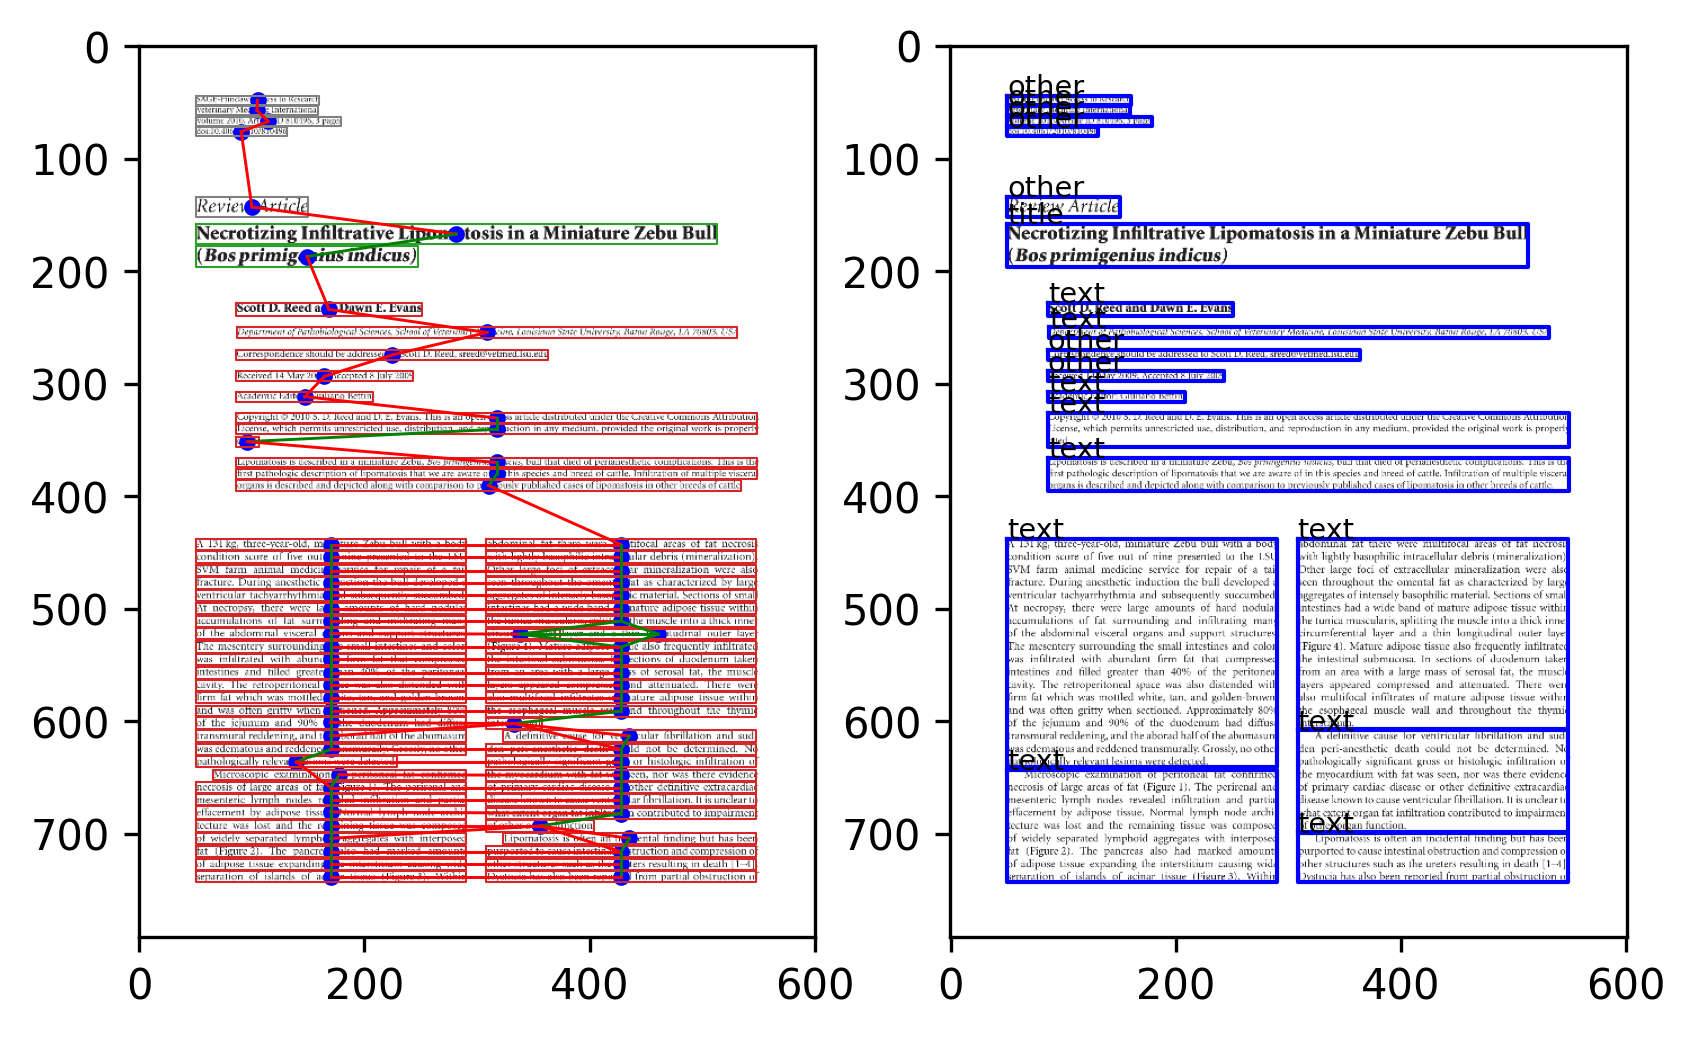

In [88]:
sample = test_dataset[12]
sample_name = sample['file_name'] + '.pdf'
print('Файл:', sample_name)
print('Нод:',  sample['N'])
print('Рёбер:', len(sample['inds'][0]) * 2)

# отрисовка через тот же ploter, что и для строк — токенизатор у нас тот же
_, sample_img = pred.get_json_and_img(Path(test_dataset_path) / sample_name)

plt.figure(dpi=300)
plt.subplot(1, 2, 1)
ploter.plot_img(sample_img)
ploter.plot_tokens(tokenizer, sample, markup=True)

plt.subplot(1,2 ,2)
ploter.plot_img(sample_img)
results = pipeline(Path(test_dataset_path) / sample_name)
for reg in results['regions']:
    reg  = Region(segment=reg['segment'], children=reg['rows'], data={"label": id2name[reg['label']]})
    reg.segment.plot(text=reg.data['label'], text_size='x-small')